Merge dos datasets

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df1 = pd.read_csv("./raw/us-financial-indicators/main.csv", parse_dates=["date"])
df2 = pd.read_csv("./raw/how-financial-crisis-are-born/global_crisis_data.csv")
df2_us = df2[df2["iso3"] == "USA"].copy()
df2_us["year"] = df2_us["year"].astype(int)

df1["year"] = df1["date"].dt.year
df1_anual = df1.groupby("year")[['Interest_Rate','Inflation','GDP',
                                  'Unemployment','Ind_Prod','sp500']].mean().reset_index()

cols_df2 = ["year","crisis_any","crisis_next_12m","banking_crisis_next_12m",
            "currency_crisis_next_12m","fed_funds_rate","real_interest_rate_10y"]
cols_df2 = [c for c in cols_df2 if c in df2_us.columns]
df_merged = pd.merge(df1_anual, df2_us[cols_df2], on="year", how="inner")

features = ["Interest_Rate", "Inflation", "GDP", "Unemployment", "Ind_Prod", "sp500"]

df_no_pca = df_merged[features + ["crisis_any", "crisis_next_12m", "year"]].dropna().reset_index(drop=True)

X_no_pca = df_no_pca[features].values
X_scaled = StandardScaler().fit_transform(X_no_pca)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["pca_1", "pca_2"])
df_pca = pd.concat(
    [df_pca, df_no_pca[["year", "crisis_any", "crisis_next_12m"]].reset_index(drop=True)],
    axis=1
)

print("Variação explicada pelos componentes PCA:", pca.explained_variance_ratio_)

Variação explicada pelos componentes PCA: [0.77203095 0.16502021]


Divisão entre dados de treino e teste

In [ ]:
from sklearn.model_selection import train_test_split

X_no_pca = df_no_pca[features]
X_pca = df_pca[["pca_1", "pca_2"]]
y = df_no_pca["crisis_next_12m"]

X_train_no_pca, X_test_no_pca, y_train_no_pca, y_test_no_pca = train_test_split(
    X_no_pca,
    y,
    test_size=0.3,
    random_state=42
)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42
)

Função base de treino, teste e plot dos modelos

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def avaliar_modelo(model, X_train, X_test, y_train, y_test, nome_modelo="Modelo"):
    
    print(f"\n===== {nome_modelo} =====")
    
    # Predições
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # ===== Classification Report =====
    print("\n--- TESTE ---")
    print(classification_report(y_test, y_pred_test))
    
    # ===== MATRIZ TREINO =====
    cm_train = confusion_matrix(y_train, y_pred_train)
    disp_train = ConfusionMatrixDisplay(cm_train, display_labels=["Sem crise", "Crise"])
    disp_train.plot()
    plt.title(f"{nome_modelo} - Matriz de Confusão (Treino)")
    plt.show()
    
    # ===== MATRIZ TESTE =====
    cm_test = confusion_matrix(y_test, y_pred_test)
    disp_test = ConfusionMatrixDisplay(cm_test, display_labels=["Sem crise", "Crise"])
    disp_test.plot()
    plt.title(f"{nome_modelo} - Matriz de Confusão (Teste)")
    plt.show()

Árvore de Decisão

Melhores parâmetros (sem PCA):
{'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

===== Decision Tree (sem PCA) =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         9
         1.0       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



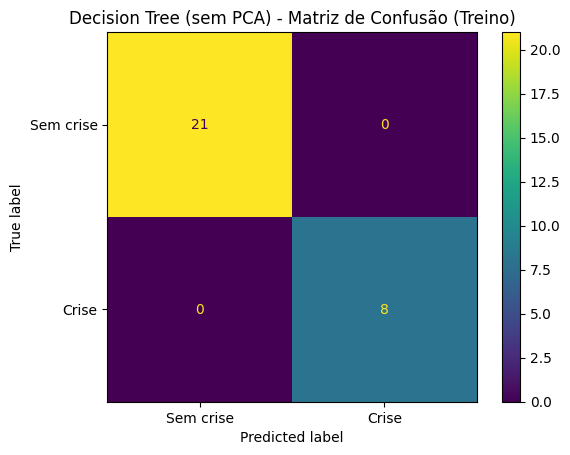

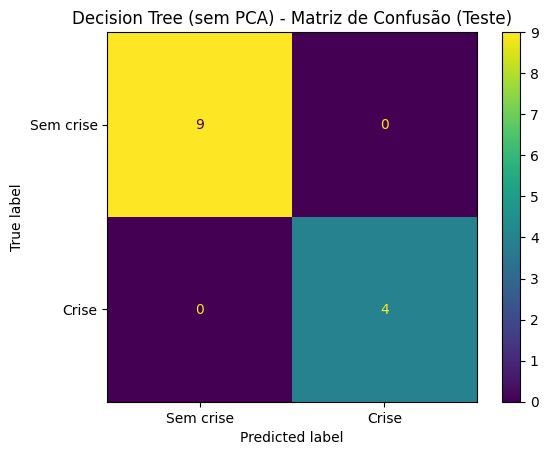

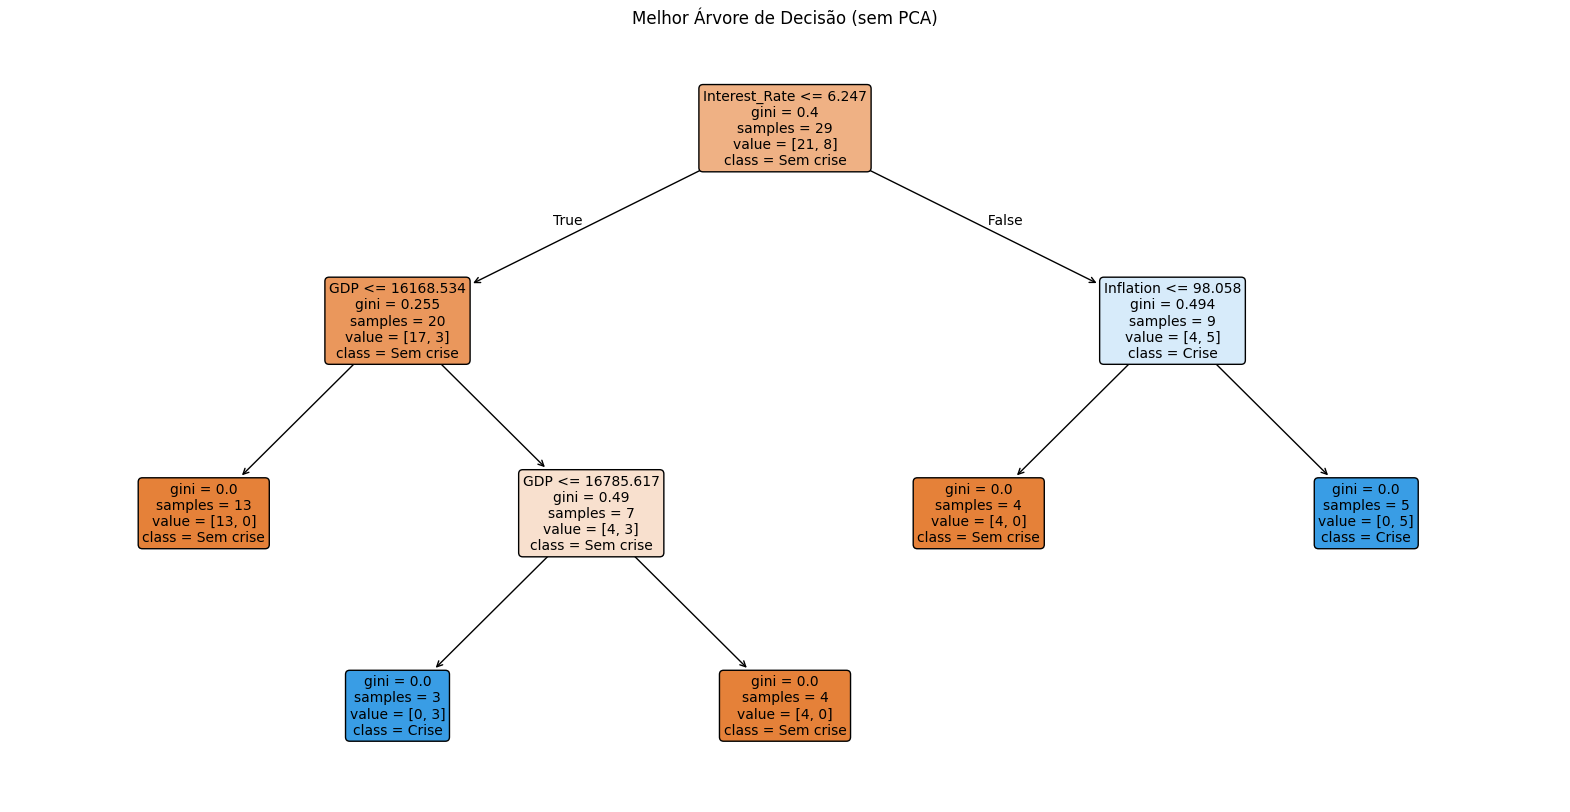

Melhores parâmetros (PCA):
{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}

===== Decision Tree (PCA) =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95         9
         1.0       1.00      0.75      0.86         4

    accuracy                           0.92        13
   macro avg       0.95      0.88      0.90        13
weighted avg       0.93      0.92      0.92        13



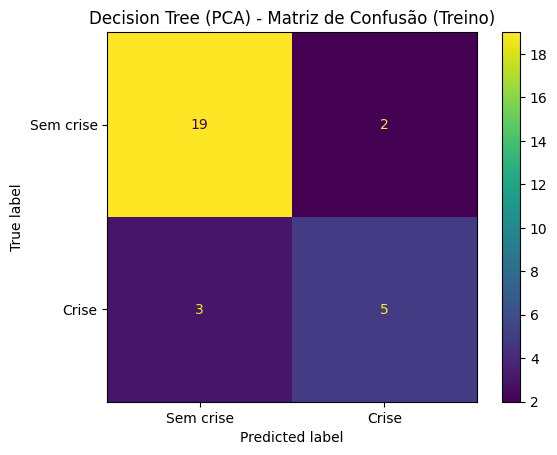

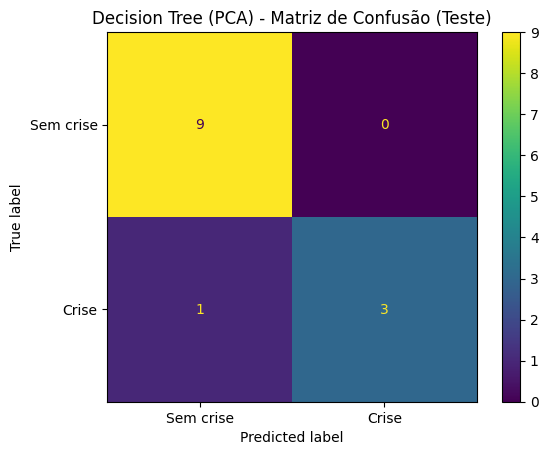

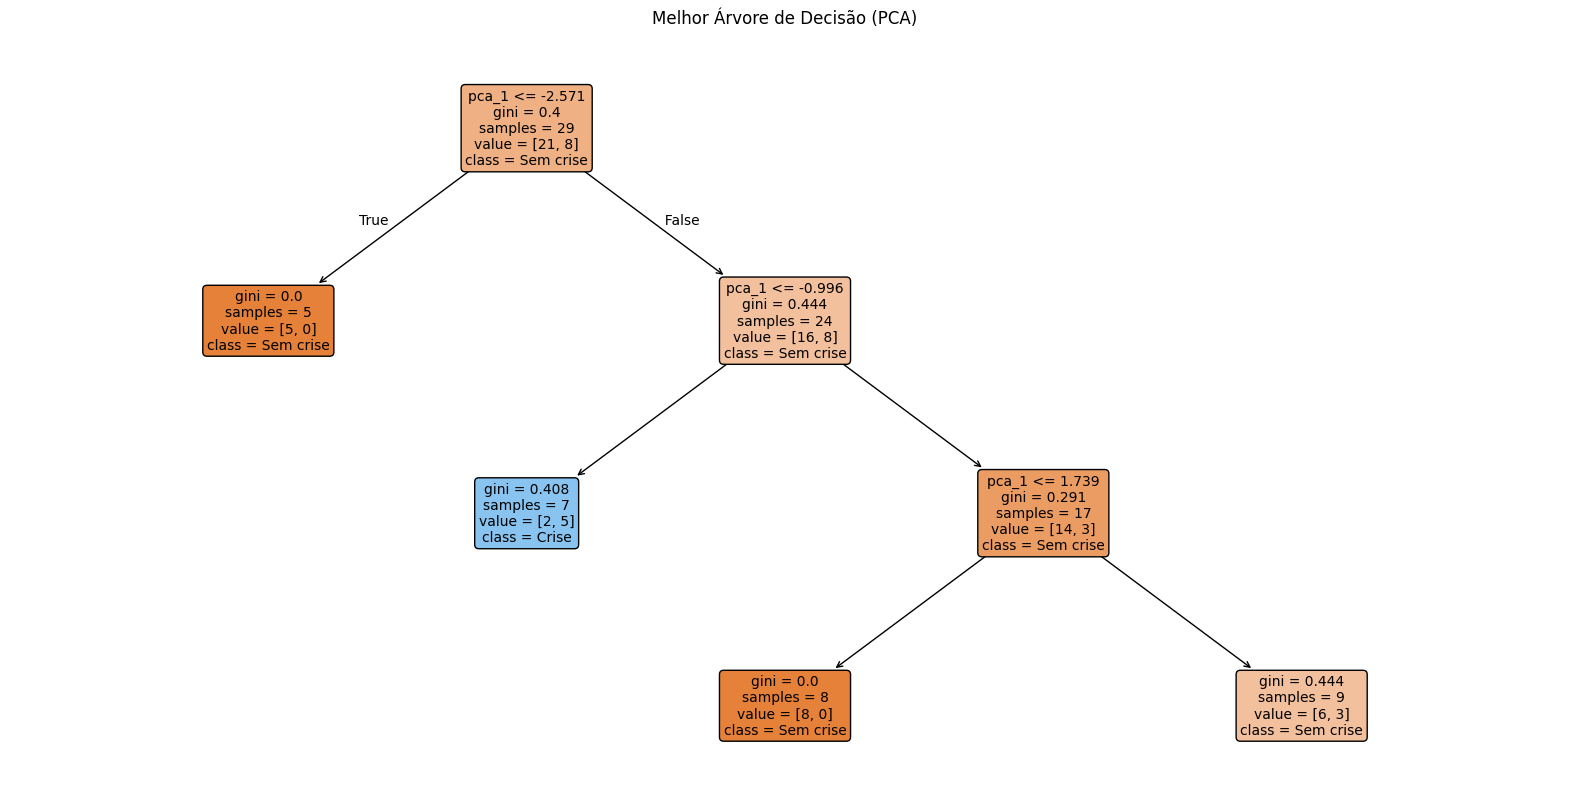

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# ===== GRID DE HIPERPARÂMETROS =====
param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# ===== MODELO BASE =====
tree = DecisionTreeClassifier(random_state=42)

# ===== TREINAR SEM PCA =====
grid_no_pca = GridSearchCV(
    tree,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

best_tree_no_pca = grid_no_pca.best_estimator_

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_tree_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Decision Tree (sem PCA)"
)

plt.figure(figsize=(20,10))
plot_tree(
    best_tree_no_pca,
    feature_names=features,
    class_names=["Sem crise", "Crise"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (sem PCA)")
plt.show()

# ===== TREINAR COM PCA =====
grid_pca = GridSearchCV(
    tree,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_pca.fit(X_train_pca, y_train_pca)

best_tree_pca = grid_pca.best_estimator_

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_tree_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Decision Tree (PCA)"
)

plt.figure(figsize=(20,10))
plot_tree(
    best_tree_pca,
    feature_names=["pca_1", "pca_2"],
    class_names=["Sem crise", "Crise"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Melhor Árvore de Decisão (PCA)")
plt.show()

KNN

Melhores parâmetros (sem PCA):
{'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'distance'}

===== KNN (sem PCA) =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95         9
         1.0       1.00      0.75      0.86         4

    accuracy                           0.92        13
   macro avg       0.95      0.88      0.90        13
weighted avg       0.93      0.92      0.92        13



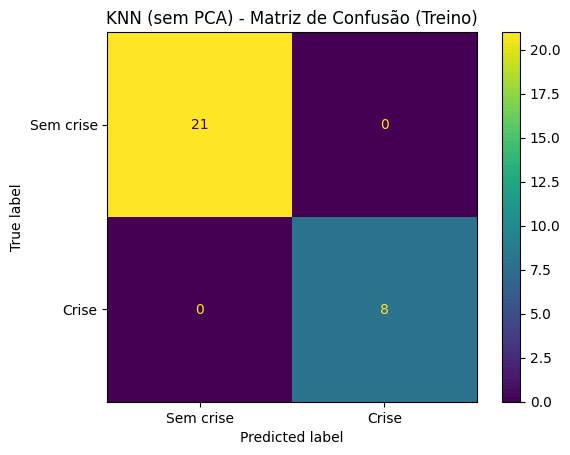

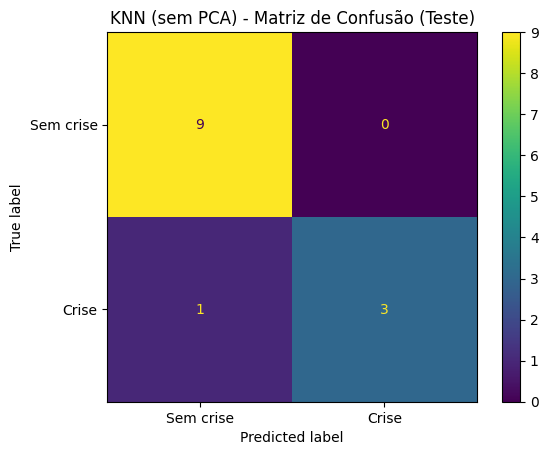

Melhores parâmetros (PCA):
{'model__metric': 'euclidean', 'model__n_neighbors': 3, 'model__weights': 'uniform'}

===== KNN (PCA) =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       0.75      1.00      0.86         9
         1.0       1.00      0.25      0.40         4

    accuracy                           0.77        13
   macro avg       0.88      0.62      0.63        13
weighted avg       0.83      0.77      0.72        13



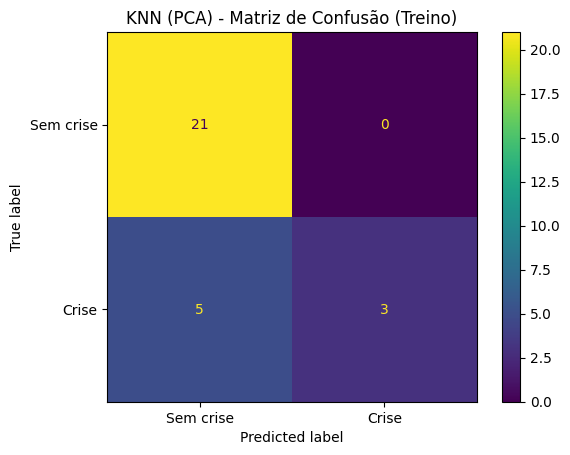

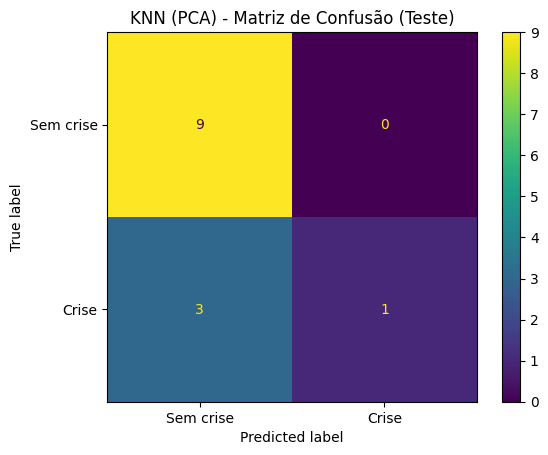

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ===== PIPELINE =====
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

# ===== GRID =====
param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

# ===== TREINAR SEM PCA =====
grid_no_pca = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

best_knn_no_pca = grid_no_pca.best_estimator_

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_knn_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="KNN (sem PCA)"
)

# ===== TREINAR COM PCA =====
grid_pca = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_pca.fit(X_train_pca, y_train_pca)

best_knn_pca = grid_pca.best_estimator_

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_knn_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="KNN (PCA)"
)

Voting Classifier


===== Voting Ensemble (sem PCA) =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         9
         1.0       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



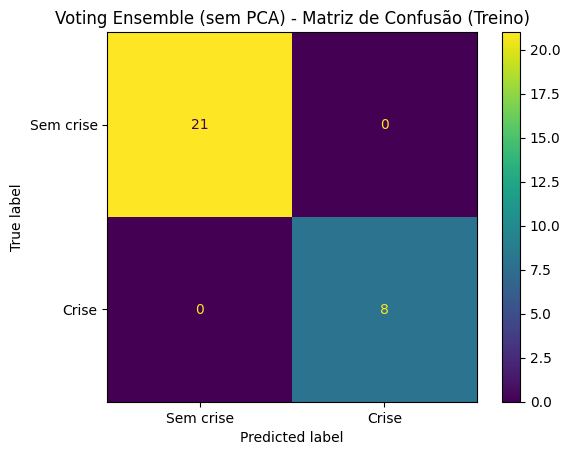

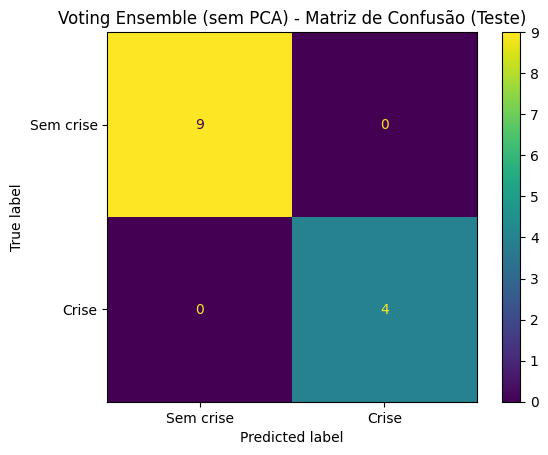


===== Voting Ensemble (PCA) =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         9
         1.0       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



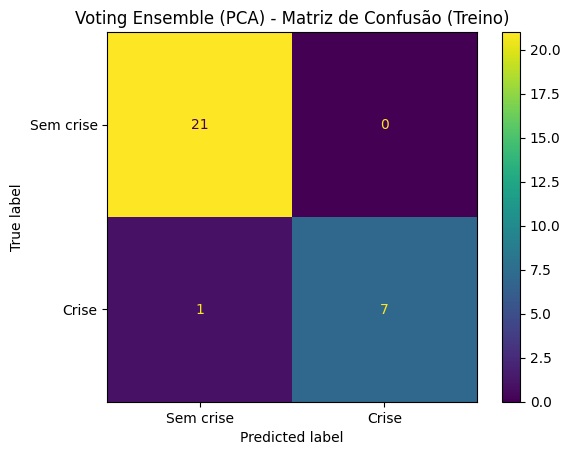

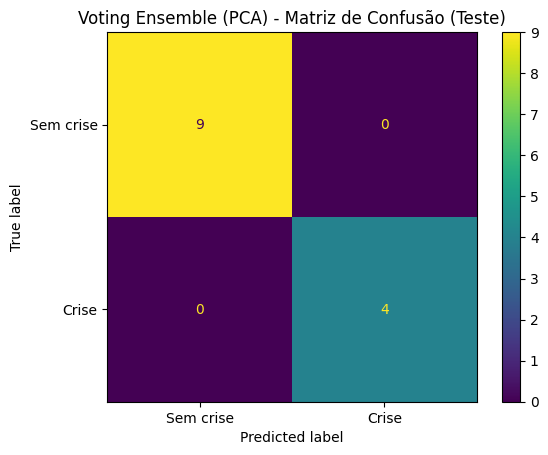

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ===== MODELOS BASE =====
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# ===== VOTING =====
voting_no_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)
voting_no_pca.fit(X_train_no_pca, y_train_no_pca)

avaliar_modelo(
    voting_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Voting Ensemble (sem PCA)"
)

# ===== TREINAR COM PCA =====
voting_pca = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)
voting_pca.fit(X_train_pca, y_train_pca)

avaliar_modelo(
    voting_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Voting Ensemble (PCA)"
)

Random Forest

Melhores parâmetros (sem PCA):
{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

===== Random Forest (sem PCA) =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         9
         1.0       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



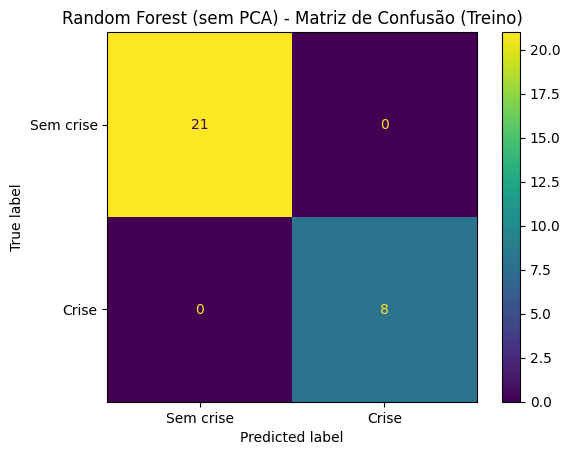

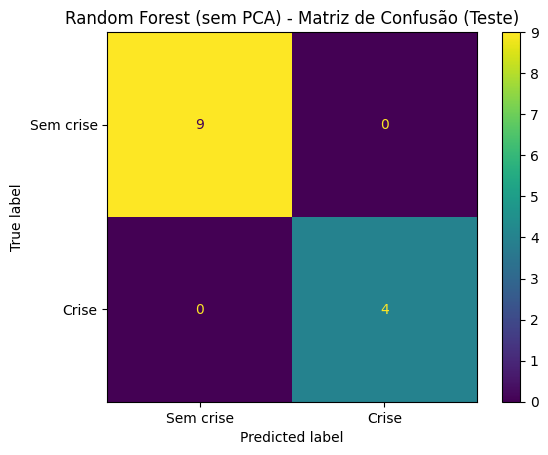


Importância das variáveis (sem PCA):
         feature  importance
1      Inflation    0.252043
0  Interest_Rate    0.189278
2            GDP    0.165178
3   Unemployment    0.140103
5          sp500    0.133793
4       Ind_Prod    0.119604


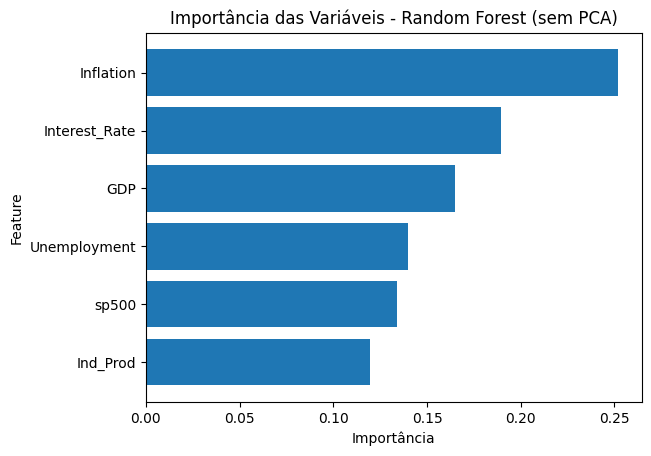

Melhores parâmetros (PCA):
{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

===== Random Forest (PCA) =====

--- TESTE ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         9
         1.0       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



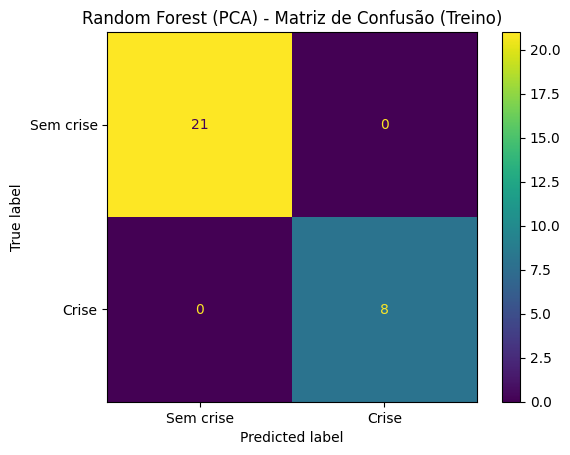

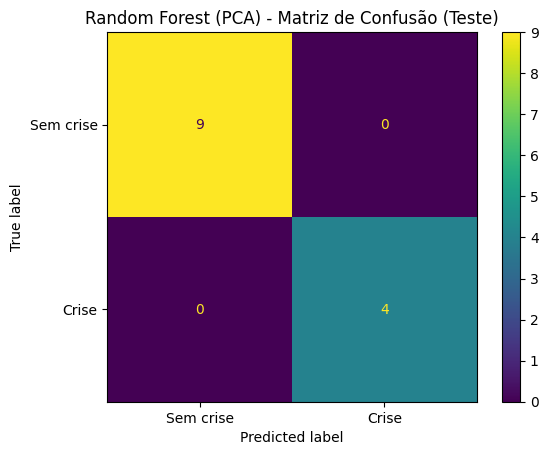


Importância das componentes PCA:
  feature  importance
0   pca_1    0.565007
1   pca_2    0.434993


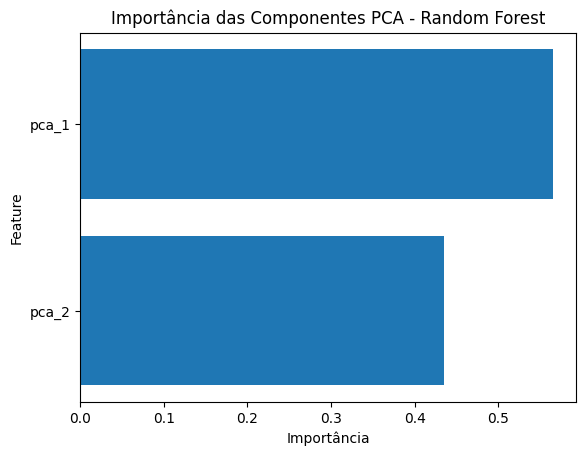

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt

# ===== GRID DE HIPERPARÂMETROS =====
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

# ===== MODELO BASE =====
rf = RandomForestClassifier(random_state=42)

# ===== TREINAR SEM PCA =====
grid_no_pca = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_no_pca.fit(X_train_no_pca, y_train_no_pca)

best_rf_no_pca = grid_no_pca.best_estimator_

print("Melhores parâmetros (sem PCA):")
print(grid_no_pca.best_params_)

avaliar_modelo(
    best_rf_no_pca,
    X_train_no_pca,
    X_test_no_pca,
    y_train_no_pca,
    y_test_no_pca,
    nome_modelo="Random Forest (sem PCA)"
)

importances = best_rf_no_pca.feature_importances_

df_importance = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nImportância das variáveis (sem PCA):")
print(df_importance)

plt.figure()
plt.barh(df_importance["feature"], df_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Variáveis - Random Forest (sem PCA)")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

# ===== TREINAR COM PCA =====
grid_pca = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_pca.fit(X_train_pca, y_train_pca)

best_rf_pca = grid_pca.best_estimator_

print("Melhores parâmetros (PCA):")
print(grid_pca.best_params_)

avaliar_modelo(
    best_rf_pca,
    X_train_pca,
    X_test_pca,
    y_train_pca,
    y_test_pca,
    nome_modelo="Random Forest (PCA)"
)

importances_pca = best_rf_pca.feature_importances_

df_importance_pca = pd.DataFrame({
    "feature": ["pca_1", "pca_2"],
    "importance": importances_pca
}).sort_values(by="importance", ascending=False)

print("\nImportância das componentes PCA:")
print(df_importance_pca)

plt.figure()
plt.barh(df_importance_pca["feature"], df_importance_pca["importance"])
plt.gca().invert_yaxis()
plt.title("Importância das Componentes PCA - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()